# Reporte de Output Curves — EGOFET

Visualización de todas las mediciones de output de un archivo HDF5.
Aquí se observan las regiones lineal y de saturación del transistor.

Para cambiar de archivo, modifica la variable `hdf5_name` en la celda de setup.


In [4]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(marker='src'):
    cwd = Path(os.getcwd()).resolve()
    for parent in [cwd, *cwd.parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(f"No se encontro project root con '{marker}'")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from src.readers.keithley_dean import list_measurements
from src.plotting import plot_output

data_folder = PROJECT_ROOT / 'data' / 'raw'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data folder:   {data_folder}")
print("Archivos disponibles:")
for f in sorted(os.listdir(data_folder)):
    print(f"  {f}")

# === Seleccionar archivo hdf5 (cambiar aqui) ===
hdf5_name = "2026-09-04_kapton_test_out.hdf5"
hdf5_path = PROJECT_ROOT / 'data' / 'raw' / hdf5_name

print("-"*80)
print(f"Archivo: {hdf5_name}")
print(f"Ruta:    {hdf5_path}")


Project root: /home/dibarra/Documents/egofets-project
Data folder:   /home/dibarra/Documents/egofets-project/data/raw
Archivos disponibles:
  2026-06-26_test1.hdf5
  2026-06-29_test2.1.hdf5
  2026-06-29_test2.hdf5
  2026-06-30_test3.hdf5
  2026-07-01_test3.hdf5
  2026-07-08_biosensing_10_-6.hdf5
  2026-07-08_biosensing_10_-6_v2.hdf5
  2026-07-08_test.hdf5
  2026-07-16_testkapton.hdf5
  2026-07-22_kapton_and_old.hdf5
  2026-07-22_kapton_v2.hdf5
  2026-07-22_kapton_v3.hdf5
  2026-07-23 TMTES PS Phototransistor v3.hdf5
  2026-08-13_test2_kapton_v3.hdf5
  2026-09-04_kapton_test_out.hdf5
  notas.txt
--------------------------------------------------------------------------------
Archivo: 2026-09-04_kapton_test_out.hdf5
Ruta:    /home/dibarra/Documents/egofets-project/data/raw/2026-09-04_kapton_test_out.hdf5


In [5]:

try:
    measurement_list_dic = list_measurements(hdf5_path)
except FileNotFoundError:
    print(f"File not found. Check the file name.\nActual name: {hdf5_path}\nPath input: {hdf5_path}")
    raise FileNotFoundError(f"File not found. Check the file name.\nActual name: {hdf5_path}\nPath input: {hdf5_path}")
except OSError as e:
    raise OSError(f'File found, but can not be opened because maybe it is corrupted.\nError: {e}')
output_measurements = [m["name"] for m in measurement_list_dic if m["mode"] == "output"]
print(f"Output measurements ({len(output_measurements)}):")
for m in output_measurements:
    print(f"  - {m}")

if len(output_measurements) == 0:
    raise ValueError("No output curve to plot in the next cell.")


Output measurements (2):
  - Batch1_disp1_03
  - Batch1_disp2_01


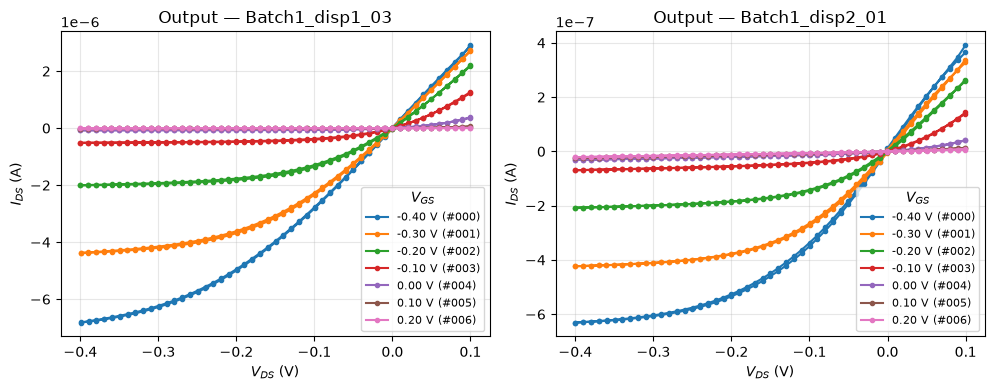

In [6]:
def plot_grid(hdf5_path, measurements, plot_func, ncols=3, figsize_per=(5, 4)):
    n = len(measurements)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    axes_flat = np.array(axes).flatten()
    for ax, m_name in zip(axes_flat, measurements):
        plot_func(hdf5_path, m_name, ax=ax)
    for ax in axes_flat[len(measurements):]:
        ax.set_visible(False)
    plt.tight_layout()
    return fig

fig = plot_grid(hdf5_path, output_measurements, plot_output)
plt.show()
